# Gold Price Prediction & Trading Strategy Framework
This notebook implements a comprehensive machine learning pipeline to forecast Gold prices (in INR per 10 grams) and develop a simple trading strategy.
Created By=
1)Parth Shinde
2)Chidambar Kulkarni

### Key Features:
* **Multi-Source Data**: Fetches data for Gold, USD/INR, Crude Oil, Silver, Nifty50, and S&P 500.
* **Feature Engineering**: Includes technical indicators like RSI, MACD, and Bollinger Bands, alongside seasonal and calendar features.
* **Model Ensemble**: Trains multiple models (XGBoost, RandomForest, LightGBM, LSTM, ARIMA) and creates a weighted ensemble.
* **Backtesting & Strategy**: Evaluates performance using walk-forward backtesting and simulates a basic 'Buy/Sell/Hold' strategy.
* **Risk & Interpretation**: Provides a macro interpretation layer and volatility-based risk assessment.

In [1]:

# 1. ENVIRONMENT SETUP, DATA COLLECTION

print("Installing and importing dependencies...")

!pip -q install yfinance requests pandas numpy scikit-learn xgboost lightgbm statsmodels tensorflow shap plotly tqdm

import warnings
warnings.filterwarnings("ignore")

import random
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import yfinance as yf
import requests

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.inspection import permutation_importance

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from statsmodels.tsa.arima.model import ARIMA

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import shap
import plotly.express as px
import plotly.graph_objects as go

# -----------------
# Global parameters
# -----------------
SEED = 42
START_DATE = "2004-01-01"
LOOKBACK = 30
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-9, "Split ratios must sum to 1.0"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

ALPHA_VANTAGE_API_KEY = "US4B9AOOCTG0SZB0"

YAHOO_TICKERS = {
    "gold_usd_oz": "GC=F",
    "usd_inr": "INR=X",
    "crude_oil": "CL=F",
    "silver_usd_oz": "SI=F",
    "nifty50": "^NSEI",
    "sp500": "^GSPC",
}

print("Environment ready.")


# =================
# 1. DATA COLLECTION
# =================
print("Step 1: Collecting market data...")


def download_yahoo_series(ticker, series_name, start_date=START_DATE, end_date=None):
    if end_date is None:
        end_date = datetime.now().date()

    df = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        progress=False,
        auto_adjust=False
    )

    if df is None or df.empty:
        raise ValueError(f"No Yahoo Finance data found for {series_name} ({ticker})")

    if isinstance(df.columns, pd.MultiIndex):
        if ("Adj Close", ticker) in df.columns:
            series = df[("Adj Close", ticker)]
        elif ("Close", ticker) in df.columns:
            series = df[("Close", ticker)]
        else:
            series = df.iloc[:, 0]
    else:
        if "Adj Close" in df.columns:
            series = df["Adj Close"]
        else:
            series = df["Close"]

    out = series.rename(series_name).to_frame().reset_index()
    out.columns = ["date", series_name]
    out["date"] = pd.to_datetime(out["date"]).dt.tz_localize(None)
    out = out.sort_values("date").reset_index(drop=True)
    return out


market_frames = {}
for series_name, ticker in YAHOO_TICKERS.items():
    print(f"Downloading {series_name}...")
    market_frames[series_name] = download_yahoo_series(ticker, series_name)

master_df = market_frames["gold_usd_oz"][["date"]].copy().sort_values("date").reset_index(drop=True)

for series_name, frame in market_frames.items():
    master_df = master_df.merge(frame, on="date", how="left")

raw_df = master_df.copy().sort_values("date").reset_index(drop=True)

print("Raw data shape:", raw_df.shape)
display(raw_df.tail())

Installing and importing dependencies...
Environment ready.
Step 1: Collecting market data...
Raw data shape: (5595, 7)


,date,gold_usd_oz,usd_inr,crude_oil,silver_usd_oz,nifty50,sp500
5590,2026-04-06,4656.799805,92.971001,112.410004,72.661003,22968.250000,6611.830078
5591,2026-04-07,4657.100098,92.816597,112.949997,71.825996,23123.650391,6616.850098
5592,2026-04-08,4749.500000,92.860199,94.410004,75.223999,23997.349609,6782.810059
5593,2026-04-09,4792.200195,92.274803,97.870003,76.277000,23775.099609,6824.660156
5594,2026-04-10,4761.899902,93.047997,96.570000,76.323997,24050.599609,6816.890137


### Explanation
**Step 0 & 1: Environment Setup and Data Collection**
* **Library Installation**: Uses `pip` to install essential ML libraries like `xgboost`, `shap`, and `yfinance`.
* **Dependencies**: Imports modules for data manipulation (`pandas`, `numpy`), visualization (`plotly`), and modeling (`scikit-learn`, `tensorflow`).
* **Data Fetching**: The `download_yahoo_series` function uses the `yfinance` API to retrieve historical adjusted closing prices for various global assets.
* **Merging**: It combines all downloaded series into a single `master_df` aligned by date.

In [2]:
# =================
# 2. PREPROCESSING
# =================
print("Step 2: Preprocessing data...")

clean_df = raw_df.copy()
clean_df["date"] = pd.to_datetime(clean_df["date"])
clean_df = clean_df.sort_values("date").drop_duplicates(subset=["date"]).reset_index(drop=True)

required_cols = ["gold_usd_oz", "usd_inr"]
for col in required_cols:
    if clean_df[col].isna().all():
        raise ValueError(f"Critical column {col} is fully missing.")

# Forward fill only to avoid future leakage from backward fill.
# This is acceptable here because each row only carries information from prior dates.
price_cols = ["gold_usd_oz", "usd_inr", "crude_oil", "silver_usd_oz", "nifty50", "sp500"]
clean_df[price_cols] = clean_df[price_cols].ffill()

# Convert international gold price into INR per 10 grams.
# Approximation:
# 1 troy ounce = 31.1034768 grams
# INR per 10g = gold_usd_oz * usd_inr * (10 / 31.1034768)
clean_df["gold_inr_10g"] = clean_df["gold_usd_oz"] * clean_df["usd_inr"] * (10.0 / 31.1034768)

# Remove rows where target price still cannot be computed.
clean_df = clean_df.dropna(subset=["gold_inr_10g"]).reset_index(drop=True)

missing_summary = clean_df.isna().mean().sort_values(ascending=False) * 100
print("Missing percentage after preprocessing:")
display(missing_summary[missing_summary > 0].round(2))

display(clean_df.tail())

Step 2: Preprocessing data...
Missing percentage after preprocessing:


,0
nifty50,16.53


,date,gold_usd_oz,usd_inr,crude_oil,silver_usd_oz,nifty50,sp500,gold_inr_10g
5590,2026-04-06,4656.799805,92.971001,112.410004,72.661003,22968.250000,6611.830078,139195.801341
5591,2026-04-07,4657.100098,92.816597,112.949997,71.825996,23123.650391,6616.850098,138973.589886
5592,2026-04-08,4749.500000,92.860199,94.410004,75.223999,23997.349609,6782.810059,141797.496745
5593,2026-04-09,4792.200195,92.274803,97.870003,76.277000,23775.099609,6824.660156,142170.385831
5594,2026-04-10,4761.899902,93.047997,96.570000,76.323997,24050.599609,6816.890137,142455.214379


### Explanation
**Step 2: Preprocessing**
* **Cleaning**: Removes duplicate dates and ensures the data is sorted chronologically.
* **Missing Values**: Implements a forward-fill (`ffill()`) strategy to prevent 'look-ahead bias' while handling missing market data.
* **Currency Conversion**: Converts international Gold prices (USD/ounce) into Indian Rupees per 10 grams using the USD/INR exchange rate and standard weight conversion factors.

In [3]:
# ======================
# 3. FEATURE ENGINEERING
# ======================
print("Step 3: Engineering features...")

feature_frame_all = clean_df.copy().sort_values("date").reset_index(drop=True)

# Targets
feature_frame_all["target_return"] = feature_frame_all["gold_inr_10g"].pct_change(1).shift(-1)
feature_frame_all["target_price"] = feature_frame_all["gold_inr_10g"].shift(-1)

# Daily returns
feature_frame_all["gold_return_1d"] = feature_frame_all["gold_inr_10g"].pct_change(1)
feature_frame_all["gold_usd_ret_1d"] = feature_frame_all["gold_usd_oz"].pct_change(1)
feature_frame_all["usd_inr_ret_1d"] = feature_frame_all["usd_inr"].pct_change(1)
feature_frame_all["crude_ret_1d"] = feature_frame_all["crude_oil"].pct_change(1)
feature_frame_all["silver_ret_1d"] = feature_frame_all["silver_usd_oz"].pct_change(1)
feature_frame_all["nifty_ret_1d"] = feature_frame_all["nifty50"].pct_change(1)
feature_frame_all["sp500_ret_1d"] = feature_frame_all["sp500"].pct_change(1)

return_cols = [
    "gold_return_1d",
    "gold_usd_ret_1d",
    "usd_inr_ret_1d",
    "crude_ret_1d",
    "silver_ret_1d",
    "nifty_ret_1d",
    "sp500_ret_1d",
]

# Lag features
for col in return_cols:
    for lag in [1, 2, 3, 5, 10]:
        feature_frame_all[f"{col}_lag{lag}"] = feature_frame_all[col].shift(lag)

# Rolling features using only past information
past_gold_ret = feature_frame_all["gold_return_1d"].shift(1)
past_usd_ret = feature_frame_all["usd_inr_ret_1d"].shift(1)
past_crude_ret = feature_frame_all["crude_ret_1d"].shift(1)
past_silver_ret = feature_frame_all["silver_ret_1d"].shift(1)
past_nifty_ret = feature_frame_all["nifty_ret_1d"].shift(1)
past_sp500_ret = feature_frame_all["sp500_ret_1d"].shift(1)

for window in [5, 10, 21, 63]:
    feature_frame_all[f"gold_ret_mean_{window}d"] = past_gold_ret.rolling(window).mean()
    feature_frame_all[f"gold_ret_std_{window}d"] = past_gold_ret.rolling(window).std()

    feature_frame_all[f"usd_ret_mean_{window}d"] = past_usd_ret.rolling(window).mean()
    feature_frame_all[f"usd_ret_std_{window}d"] = past_usd_ret.rolling(window).std()

    feature_frame_all[f"crude_ret_mean_{window}d"] = past_crude_ret.rolling(window).mean()
    feature_frame_all[f"crude_ret_std_{window}d"] = past_crude_ret.rolling(window).std()

    feature_frame_all[f"silver_ret_mean_{window}d"] = past_silver_ret.rolling(window).mean()
    feature_frame_all[f"silver_ret_std_{window}d"] = past_silver_ret.rolling(window).std()

    feature_frame_all[f"nifty_ret_mean_{window}d"] = past_nifty_ret.rolling(window).mean()
    feature_frame_all[f"nifty_ret_std_{window}d"] = past_nifty_ret.rolling(window).std()

    feature_frame_all[f"sp500_ret_mean_{window}d"] = past_sp500_ret.rolling(window).mean()
    feature_frame_all[f"sp500_ret_std_{window}d"] = past_sp500_ret.rolling(window).std()


def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0).rolling(period).mean()
    loss = (-delta.clip(upper=0)).rolling(period).mean()
    rs = gain / loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


past_gold_price = feature_frame_all["gold_inr_10g"].shift(1)

# RSI
feature_frame_all["rsi_14"] = compute_rsi(past_gold_price, 14)
feature_frame_all["rsi_7"] = compute_rsi(past_gold_price, 7)

# MACD
ema_12 = past_gold_price.ewm(span=12, adjust=False).mean()
ema_26 = past_gold_price.ewm(span=26, adjust=False).mean()
feature_frame_all["macd"] = ema_12 - ema_26
feature_frame_all["macd_signal"] = feature_frame_all["macd"].ewm(span=9, adjust=False).mean()
feature_frame_all["macd_hist"] = feature_frame_all["macd"] - feature_frame_all["macd_signal"]

# Bollinger Bands
bb_mid = past_gold_price.rolling(20).mean()
bb_std = past_gold_price.rolling(20).std()
feature_frame_all["bb_upper"] = bb_mid + 2 * bb_std
feature_frame_all["bb_lower"] = bb_mid - 2 * bb_std
feature_frame_all["bb_width"] = (feature_frame_all["bb_upper"] - feature_frame_all["bb_lower"]) / bb_mid
feature_frame_all["bb_pct"] = (
    (past_gold_price - feature_frame_all["bb_lower"]) /
    (feature_frame_all["bb_upper"] - feature_frame_all["bb_lower"])
)

# Calendar features
feature_frame_all["day_of_week"] = feature_frame_all["date"].dt.dayofweek
feature_frame_all["month"] = feature_frame_all["date"].dt.month
feature_frame_all["quarter"] = feature_frame_all["date"].dt.quarter
feature_frame_all["week_of_year"] = feature_frame_all["date"].dt.isocalendar().week.astype(int)
feature_frame_all["month_sin"] = np.sin(2 * np.pi * feature_frame_all["month"] / 12)
feature_frame_all["month_cos"] = np.cos(2 * np.pi * feature_frame_all["month"] / 12)
feature_frame_all["is_month_end"] = feature_frame_all["date"].dt.is_month_end.astype(int)
feature_frame_all["is_quarter_end"] = feature_frame_all["date"].dt.is_quarter_end.astype(int)

# Standardized seasonal proxy names
feature_frame_all["festival_season"] = feature_frame_all["month"].isin([10, 11]).astype(int)
feature_frame_all["akshaya_tritiya_season"] = feature_frame_all["month"].isin([4, 5]).astype(int)
feature_frame_all["wedding_season"] = feature_frame_all["month"].isin([1, 2, 4, 5, 11, 12]).astype(int)

# Clean infinite values
feature_frame_all = feature_frame_all.replace([np.inf, -np.inf], np.nan)

exclude_from_features = [
    "date",
    "gold_inr_10g",
    "gold_usd_oz",
    "usd_inr",
    "crude_oil",
    "silver_usd_oz",
    "nifty50",
    "sp500",
    "target_return",
    "target_price",
]

feature_cols = [col for col in feature_frame_all.columns if col not in exclude_from_features]

model_df = feature_frame_all.dropna(subset=feature_cols + ["target_return", "target_price"]).reset_index(drop=True)

print("Number of feature columns:", len(feature_cols))
print("Model dataset shape:", model_df.shape)
display(model_df[["date", "gold_inr_10g", "target_return", "target_price"]].tail())

Step 3: Engineering features...
Number of feature columns: 110
Model dataset shape: (4562, 120)


,date,gold_inr_10g,target_return,target_price
4557,2026-04-02,138546.266510,0.004688,139195.801341
4558,2026-04-06,139195.801341,-0.001596,138973.589886
4559,2026-04-07,138973.589886,0.020320,141797.496745
4560,2026-04-08,141797.496745,0.002630,142170.385831
4561,2026-04-09,142170.385831,0.002003,142455.214379


### Explanation
**Step 3: Feature Engineering**
* **Targets**: Creates the target variables—next-day returns and next-day prices.
* **Technical Indicators**: Calculates momentum (RSI), trend (MACD), and volatility (Bollinger Bands) indicators.
* **Time-Series Features**: Generates lag features (past 1 to 10 days) and rolling means/standard deviations to capture historical trends.
* **Seasonality**: Adds binary flags for Indian specific events like the Wedding Season and Akshaya Tritiya, which historically impact gold demand.

In [4]:
# ==============================
# 4. TRAIN/TEST SPLIT (TIME-BASED)
# ==============================
print("Step 4: Creating strict time-based train/validation/test split...")

X_all = model_df[feature_cols].copy()
y_all_return = model_df["target_return"].copy()
y_all_price = model_df["target_price"].copy()
current_price_all = model_df["gold_inr_10g"].copy()
dates_all = model_df["date"].copy()

n_obs = len(model_df)
train_end = int(n_obs * TRAIN_RATIO)
val_end = int(n_obs * (TRAIN_RATIO + VAL_RATIO))

X_train_raw = X_all.iloc[:train_end].copy()
X_val_raw = X_all.iloc[train_end:val_end].copy()
X_test_raw = X_all.iloc[val_end:].copy()

y_train_return = y_all_return.iloc[:train_end].copy()
y_val_return = y_all_return.iloc[train_end:val_end].copy()
y_test_return = y_all_return.iloc[val_end:].copy()

y_train_price = y_all_price.iloc[:train_end].copy()
y_val_price = y_all_price.iloc[train_end:val_end].copy()
y_test_price = y_all_price.iloc[val_end:].copy()

current_price_train = current_price_all.iloc[:train_end].copy()
current_price_val = current_price_all.iloc[train_end:val_end].copy()
current_price_test = current_price_all.iloc[val_end:].copy()

dates_train = dates_all.iloc[:train_end].copy()
dates_val = dates_all.iloc[train_end:val_end].copy()
dates_test = dates_all.iloc[val_end:].copy()

print("Train rows:", len(X_train_raw))
print("Validation rows:", len(X_val_raw))
print("Test rows:", len(X_test_raw))
print("Train range:", dates_train.min().date(), "to", dates_train.max().date())
print("Validation range:", dates_val.min().date(), "to", dates_val.max().date())
print("Test range:", dates_test.min().date(), "to", dates_test.max().date())


Step 4: Creating strict time-based train/validation/test split...
Train rows: 3193
Validation rows: 684
Test rows: 685
Train range: 2007-12-17 to 2020-10-05
Validation range: 2020-10-06 to 2023-07-06
Test range: 2023-07-07 to 2026-04-09


### Explanation
**Step 4: Train/Test Split**
* **Time-Based Splitting**: Crucially, it uses a chronological split (70% Train, 15% Validation, 15% Test) rather than a random split. This ensures the model is tested on 'future' data it hasn't seen, mimicking real-world conditions.

In [5]:
# ============================
# 5. SCALING (NO DATA LEAKAGE)
# ============================
print("Step 5: Scaling features without leakage...")

# StandardScaler for linear model
std_scaler = StandardScaler()
X_train_std = std_scaler.fit_transform(X_train_raw)
X_val_std = std_scaler.transform(X_val_raw)
X_test_std = std_scaler.transform(X_test_raw)

# MinMaxScaler for LSTM
lstm_x_scaler = MinMaxScaler()
lstm_y_scaler = MinMaxScaler()

lstm_x_scaler.fit(X_train_raw)
lstm_y_scaler.fit(y_train_return.values.reshape(-1, 1))

X_all_lstm = lstm_x_scaler.transform(X_all)
y_all_lstm = lstm_y_scaler.transform(y_all_return.values.reshape(-1, 1)).flatten()


def make_sequences(X_scaled, y_scaled, start_idx, end_idx, lookback):
    X_seq, y_seq, row_ids = [], [], []
    for i in range(start_idx, end_idx):
        if i < lookback - 1:
            continue
        window = X_scaled[i - lookback + 1:i + 1]
        if len(window) != lookback:
            continue
        X_seq.append(window)
        y_seq.append(y_scaled[i])
        row_ids.append(i)
    return np.array(X_seq), np.array(y_seq), np.array(row_ids)


X_train_lstm, y_train_lstm, idx_train_lstm = make_sequences(X_all_lstm, y_all_lstm, 0, train_end, LOOKBACK)
X_val_lstm, y_val_lstm, idx_val_lstm = make_sequences(X_all_lstm, y_all_lstm, train_end, val_end, LOOKBACK)
X_test_lstm, y_test_lstm, idx_test_lstm = make_sequences(X_all_lstm, y_all_lstm, val_end, n_obs, LOOKBACK)

current_price_val_lstm = current_price_all.iloc[idx_val_lstm].values
current_price_test_lstm = current_price_all.iloc[idx_test_lstm].values
y_val_price_lstm = y_all_price.iloc[idx_val_lstm].values
y_test_price_lstm = y_all_price.iloc[idx_test_lstm].values

print("LSTM train shape:", X_train_lstm.shape)
print("LSTM validation shape:", X_val_lstm.shape)
print("LSTM test shape:", X_test_lstm.shape)

Step 5: Scaling features without leakage...
LSTM train shape: (3164, 30, 110)
LSTM validation shape: (684, 30, 110)
LSTM test shape: (685, 30, 110)


### Explanation
**Step 5: Scaling**
* **Standardization**: Applies `StandardScaler` for linear models and `MinMaxScaler` for the Neural Network (LSTM).
* **Sequence Creation**: The `make_sequences` function transforms the 2D tabular data into a 3D format (samples, time steps, features) required by the LSTM model to process the 30-day lookback window.

In [6]:
# =================
# 6. MODEL TRAINING
# =================
print("Step 6: Training models...")

def return_to_price(current_price, predicted_return):
    return np.array(current_price) * (1.0 + np.array(predicted_return))


def price_metrics(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    denom = np.where(np.abs(y_true) < 1e-8, np.nan, y_true)
    mape = np.nanmean(np.abs((y_true - y_pred) / denom)) * 100
    r2 = r2_score(y_true, y_pred)

    return {
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4),
        "MAPE": round(mape, 4),
        "R2": round(r2, 6),
    }


trained_models = {}
val_pred_price = {}
test_pred_price = {}

val_rows = []
test_rows = []

# Linear Regression
print("Training LinearRegression...")
linear_regression = LinearRegression()
linear_regression.fit(X_train_std, y_train_return)

lr_val_pred_price = return_to_price(current_price_val.values, linear_regression.predict(X_val_std))
lr_test_pred_price = return_to_price(current_price_test.values, linear_regression.predict(X_test_std))

trained_models["LinearRegression"] = linear_regression
val_pred_price["LinearRegression"] = lr_val_pred_price
test_pred_price["LinearRegression"] = lr_test_pred_price

metrics = price_metrics(y_val_price.values, lr_val_pred_price)
metrics["Model"] = "LinearRegression"
val_rows.append(metrics)

metrics = price_metrics(y_test_price.values, lr_test_pred_price)
metrics["Model"] = "LinearRegression"
test_rows.append(metrics)

# Random Forest
print("Training RandomForest...")
random_forest = RandomForestRegressor(
    n_estimators=500,
    max_depth=5,
    min_samples_leaf=20,
    min_samples_split=40,
    max_features="sqrt",
    random_state=SEED,
    n_jobs=-1
)
random_forest.fit(X_train_raw, y_train_return)

rf_val_pred_price = return_to_price(current_price_val.values, random_forest.predict(X_val_raw))
rf_test_pred_price = return_to_price(current_price_test.values, random_forest.predict(X_test_raw))

trained_models["RandomForest"] = random_forest
val_pred_price["RandomForest"] = rf_val_pred_price
test_pred_price["RandomForest"] = rf_test_pred_price

metrics = price_metrics(y_val_price.values, rf_val_pred_price)
metrics["Model"] = "RandomForest"
val_rows.append(metrics)

metrics = price_metrics(y_test_price.values, rf_test_pred_price)
metrics["Model"] = "RandomForest"
test_rows.append(metrics)

# XGBoost
print("Training XGBoost...")
xgboost_model = XGBRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.03,
    min_child_weight=10,
    subsample=0.80,
    colsample_bytree=0.80,
    gamma=1.0,
    reg_alpha=0.5,
    reg_lambda=5.0,
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1
)
xgboost_model.fit(X_train_raw, y_train_return)

xgb_val_pred_price = return_to_price(current_price_val.values, xgboost_model.predict(X_val_raw))
xgb_test_pred_price = return_to_price(current_price_test.values, xgboost_model.predict(X_test_raw))

trained_models["XGBoost"] = xgboost_model
val_pred_price["XGBoost"] = xgb_val_pred_price
test_pred_price["XGBoost"] = xgb_test_pred_price

metrics = price_metrics(y_val_price.values, xgb_val_pred_price)
metrics["Model"] = "XGBoost"
val_rows.append(metrics)

metrics = price_metrics(y_test_price.values, xgb_test_pred_price)
metrics["Model"] = "XGBoost"
test_rows.append(metrics)

# LightGBM
print("Training LightGBM...")
lightgbm_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.03,
    num_leaves=15,
    max_depth=3,
    min_child_samples=40,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_alpha=0.5,
    reg_lambda=5.0,
    random_state=SEED,
    verbose=-1
)
lightgbm_model.fit(X_train_raw, y_train_return)

lgbm_val_pred_price = return_to_price(current_price_val.values, lightgbm_model.predict(X_val_raw))
lgbm_test_pred_price = return_to_price(current_price_test.values, lightgbm_model.predict(X_test_raw))

trained_models["LightGBM"] = lightgbm_model
val_pred_price["LightGBM"] = lgbm_val_pred_price
test_pred_price["LightGBM"] = lgbm_test_pred_price

metrics = price_metrics(y_val_price.values, lgbm_val_pred_price)
metrics["Model"] = "LightGBM"
val_rows.append(metrics)

metrics = price_metrics(y_test_price.values, lgbm_test_pred_price)
metrics["Model"] = "LightGBM"
test_rows.append(metrics)

# ARIMA on returns
print("Training ARIMA...")
arima_train_series = pd.concat([y_train_return, y_val_return]).dropna()
arima_model = ARIMA(
    arima_train_series,
    order=(1, 0, 1),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()

arima_val_forecast = arima_model.forecast(steps=len(y_val_return))
arima_test_model = ARIMA(
    pd.concat([y_train_return, y_val_return]).dropna(),
    order=(1, 0, 1),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()
arima_test_forecast = arima_test_model.forecast(steps=len(y_test_return))

arima_val_pred_price = return_to_price(current_price_val.values, arima_val_forecast)
arima_test_pred_price = return_to_price(current_price_test.values, arima_test_forecast)

trained_models["ARIMA"] = arima_test_model
val_pred_price["ARIMA"] = arima_val_pred_price
test_pred_price["ARIMA"] = arima_test_pred_price

metrics = price_metrics(y_val_price.values, arima_val_pred_price)
metrics["Model"] = "ARIMA"
val_rows.append(metrics)

metrics = price_metrics(y_test_price.values, arima_test_pred_price)
metrics["Model"] = "ARIMA"
test_rows.append(metrics)

# LSTM
print("Training LSTM...")
lstm_model = Sequential([
    Input(shape=(LOOKBACK, len(feature_cols))),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer="adam", loss="mse")

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

if len(X_train_lstm) > 0 and len(X_val_lstm) > 0:
    lstm_model.fit(
        X_train_lstm,
        y_train_lstm,
        validation_data=(X_val_lstm, y_val_lstm),
        epochs=50,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0
    )

    lstm_val_pred_return_scaled = lstm_model.predict(X_val_lstm, verbose=0).flatten()
    lstm_test_pred_return_scaled = lstm_model.predict(X_test_lstm, verbose=0).flatten()

    lstm_val_pred_return = lstm_y_scaler.inverse_transform(lstm_val_pred_return_scaled.reshape(-1, 1)).flatten()
    lstm_test_pred_return = lstm_y_scaler.inverse_transform(lstm_test_pred_return_scaled.reshape(-1, 1)).flatten()

    lstm_val_pred_price = return_to_price(current_price_val_lstm, lstm_val_pred_return)
    lstm_test_pred_price = return_to_price(current_price_test_lstm, lstm_test_pred_return)

    trained_models["LSTM"] = lstm_model
    val_pred_price["LSTM"] = lstm_val_pred_price
    test_pred_price["LSTM"] = lstm_test_pred_price

    metrics = price_metrics(y_val_price_lstm, lstm_val_pred_price)
    metrics["Model"] = "LSTM"
    val_rows.append(metrics)

    metrics = price_metrics(y_test_price_lstm, lstm_test_pred_price)
    metrics["Model"] = "LSTM"
    test_rows.append(metrics)

val_results_df = pd.DataFrame(val_rows)[["Model", "RMSE", "MAE", "MAPE", "R2"]].sort_values("RMSE").reset_index(drop=True)
test_results_df = pd.DataFrame(test_rows)[["Model", "RMSE", "MAE", "MAPE", "R2"]].sort_values("RMSE").reset_index(drop=True)

print("Validation results:")
display(val_results_df)

print("Test results:")
display(test_results_df)

Step 6: Training models...
Training LinearRegression...
Training RandomForest...
Training XGBoost...
Training LightGBM...
Training ARIMA...
Training LSTM...
Validation results:


,Model,RMSE,MAE,MAPE,R2
0,RandomForest,443.4664,329.1610,0.7245,0.981367
1,LSTM,446.5585,332.8243,0.7323,0.981107
2,ARIMA,447.0576,332.9483,0.7327,0.981064
3,XGBoost,447.1384,332.9358,0.7327,0.981058
4,LightGBM,447.7831,334.0944,0.7354,0.981003
5,LinearRegression,461.8120,351.6114,0.7724,0.979794


Test results:


,Model,RMSE,MAE,MAPE,R2
0,XGBoost,1276.8500,806.6551,0.8953,0.997990
1,ARIMA,1277.4029,807.0197,0.8955,0.997988
2,RandomForest,1279.6608,806.7198,0.8948,0.997981
3,LightGBM,1279.8781,808.4873,0.8982,0.997980
4,LSTM,1318.9211,833.1025,0.9182,0.997855
5,LinearRegression,1809.6051,1121.2569,1.2041,0.995962


### Explanation
**Step 6: Model Training**
* **Algorithm Variety**: Trains a diverse set of models including Linear Regression, Random Forest, XGBoost, LightGBM, ARIMA, and a Deep Learning LSTM.
* **Evaluation Metrics**: Uses RMSE, MAE, and R-squared to evaluate how well each model predicts the actual price on the validation set.

In [7]:
# =============
# 7. EVALUATION
# =============
print("Step 7: Evaluating models...")

final_comparison_df = val_results_df.merge(
    test_results_df,
    on="Model",
    suffixes=("_val", "_test")
).sort_values("RMSE_test").reset_index(drop=True)

display(final_comparison_df)

best_model_name = final_comparison_df.iloc[0]["Model"]
print("Best model on test set:", best_model_name)

Step 7: Evaluating models...


,Model,RMSE_val,MAE_val,MAPE_val,R2_val,RMSE_test,MAE_test,MAPE_test,R2_test
0,XGBoost,447.1384,332.9358,0.7327,0.981058,1276.8500,806.6551,0.8953,0.997990
1,ARIMA,447.0576,332.9483,0.7327,0.981064,1277.4029,807.0197,0.8955,0.997988
2,RandomForest,443.4664,329.1610,0.7245,0.981367,1279.6608,806.7198,0.8948,0.997981
3,LightGBM,447.7831,334.0944,0.7354,0.981003,1279.8781,808.4873,0.8982,0.997980
4,LSTM,446.5585,332.8243,0.7323,0.981107,1318.9211,833.1025,0.9182,0.997855
5,LinearRegression,461.8120,351.6114,0.7724,0.979794,1809.6051,1121.2569,1.2041,0.995962


Best model on test set: XGBoost


### Explanation
**Step 7: Evaluation**
* **Model Comparison**: Compares the results of all models on the unseen Test set to identify the most accurate predictor. Based on the output, XGBoost is identified as the best performing standalone model.

In [8]:
# ============
# 8. ENSEMBLE
# ============
print("Step 8: Building weighted ensemble...")

# Use only aligned tabular models for ensemble.
tabular_model_names = ["LinearRegression", "RandomForest", "XGBoost", "LightGBM"]

eligible_models = val_results_df[
    val_results_df["Model"].isin(tabular_model_names) &
    (val_results_df["R2"] > 0)
].copy()

if eligible_models.empty:
    raise ValueError("No eligible tabular models found for ensemble.")

best_rmse = eligible_models["RMSE"].min()
eligible_models = eligible_models[eligible_models["RMSE"] <= best_rmse * 1.5].copy()
eligible_models = eligible_models.sort_values("RMSE").head(3).copy()

eligible_models["inv_rmse"] = 1.0 / eligible_models["RMSE"]
eligible_models["Weight"] = eligible_models["inv_rmse"] / eligible_models["inv_rmse"].sum()

ensemble_weights_df = eligible_models[["Model", "RMSE", "Weight"]].sort_values("Weight", ascending=False).reset_index(drop=True)

print("Ensemble weights:")
display(ensemble_weights_df)

ensemble_val_pred_price = np.zeros(len(y_val_price))
ensemble_test_pred_price = np.zeros(len(y_test_price))

for _, row in ensemble_weights_df.iterrows():
    model_name = row["Model"]
    weight = float(row["Weight"])
    ensemble_val_pred_price += weight * np.array(val_pred_price[model_name])
    ensemble_test_pred_price += weight * np.array(test_pred_price[model_name])

ensemble_val_metrics = price_metrics(y_val_price.values, ensemble_val_pred_price)
ensemble_val_metrics["Model"] = "Ensemble"

ensemble_test_metrics = price_metrics(y_test_price.values, ensemble_test_pred_price)
ensemble_test_metrics["Model"] = "Ensemble"

val_pred_price["Ensemble"] = ensemble_val_pred_price
test_pred_price["Ensemble"] = ensemble_test_pred_price

val_results_with_ensemble = pd.concat(
    [val_results_df, pd.DataFrame([ensemble_val_metrics])[["Model", "RMSE", "MAE", "MAPE", "R2"]]],
    ignore_index=True
).sort_values("RMSE").reset_index(drop=True)

test_results_with_ensemble = pd.concat(
    [test_results_df, pd.DataFrame([ensemble_test_metrics])[["Model", "RMSE", "MAE", "MAPE", "R2"]]],
    ignore_index=True
).sort_values("RMSE").reset_index(drop=True)

final_comparison_df = val_results_with_ensemble.merge(
    test_results_with_ensemble,
    on="Model",
    suffixes=("_val", "_test")
).sort_values("RMSE_test").reset_index(drop=True)

print("Final comparison including ensemble:")
display(final_comparison_df)


Step 8: Building weighted ensemble...
Ensemble weights:


,Model,RMSE,Weight
0,RandomForest,443.4664,0.335329
1,XGBoost,447.1384,0.332575
2,LightGBM,447.7831,0.332096


Final comparison including ensemble:


,Model,RMSE_val,MAE_val,MAPE_val,R2_val,RMSE_test,MAE_test,MAPE_test,R2_test
0,Ensemble,444.3919,330.4408,0.7273,0.981290,1276.6053,805.3202,0.8936,0.997990
1,XGBoost,447.1384,332.9358,0.7327,0.981058,1276.8500,806.6551,0.8953,0.997990
2,ARIMA,447.0576,332.9483,0.7327,0.981064,1277.4029,807.0197,0.8955,0.997988
3,RandomForest,443.4664,329.1610,0.7245,0.981367,1279.6608,806.7198,0.8948,0.997981
4,LightGBM,447.7831,334.0944,0.7354,0.981003,1279.8781,808.4873,0.8982,0.997980
5,LSTM,446.5585,332.8243,0.7323,0.981107,1318.9211,833.1025,0.9182,0.997855
6,LinearRegression,461.8120,351.6114,0.7724,0.979794,1809.6051,1121.2569,1.2041,0.995962


### Explanation
**Step 8: Ensemble Building**
* **Weighting**: Creates a 'Super Model' by combining the top 3 performing tabular models. The weights are assigned based on the inverse of their RMSE (lower error equals higher weight).

In [9]:
# ===============
# 9. BACKTESTING
# ===============
print("Step 9: Running walk-forward backtesting...")

# Use best weighted tabular model for backtesting for clean alignment and reproducibility.
backtest_model_name = ensemble_weights_df.iloc[0]["Model"]
print("Backtesting model:", backtest_model_name)


def make_backtest_model(model_name):
    if model_name == "RandomForest":
        return RandomForestRegressor(
            n_estimators=500,
            max_depth=5,
            min_samples_leaf=20,
            min_samples_split=40,
            max_features="sqrt",
            random_state=SEED,
            n_jobs=-1
        )
    if model_name == "XGBoost":
        return XGBRegressor(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.03,
            min_child_weight=10,
            subsample=0.80,
            colsample_bytree=0.80,
            gamma=1.0,
            reg_alpha=0.5,
            reg_lambda=5.0,
            objective="reg:squarederror",
            random_state=SEED,
            n_jobs=-1
        )
    if model_name == "LightGBM":
        return LGBMRegressor(
            n_estimators=300,
            learning_rate=0.03,
            num_leaves=15,
            max_depth=3,
            min_child_samples=40,
            subsample=0.80,
            colsample_bytree=0.80,
            reg_alpha=0.5,
            reg_lambda=5.0,
            random_state=SEED,
            verbose=-1
        )
    if model_name == "LinearRegression":
        return LinearRegression()
    raise ValueError(f"Unknown model name: {model_name}")


tscv = TimeSeriesSplit(n_splits=5)

fold_rows = []
fold_plot_frames = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_all), start=1):
    X_bt_train = X_all.iloc[train_idx].copy()
    X_bt_test = X_all.iloc[test_idx].copy()

    y_bt_train = y_all_return.iloc[train_idx].copy()
    y_bt_test_price = y_all_price.iloc[test_idx].copy()
    current_bt_test = current_price_all.iloc[test_idx].copy()
    dates_bt_test = dates_all.iloc[test_idx].copy()

    model_bt = make_backtest_model(backtest_model_name)

    if backtest_model_name == "LinearRegression":
        bt_scaler = StandardScaler()
        X_bt_train_scaled = bt_scaler.fit_transform(X_bt_train)
        X_bt_test_scaled = bt_scaler.transform(X_bt_test)
        model_bt.fit(X_bt_train_scaled, y_bt_train)
        pred_bt_return = model_bt.predict(X_bt_test_scaled)
    else:
        model_bt.fit(X_bt_train, y_bt_train)
        pred_bt_return = model_bt.predict(X_bt_test)

    pred_bt_price = return_to_price(current_bt_test.values, pred_bt_return)

    fold_metrics = price_metrics(y_bt_test_price.values, pred_bt_price)
    fold_metrics["Fold"] = fold
    fold_rows.append(fold_metrics)

    fold_plot_frames.append(pd.DataFrame({
        "date": dates_bt_test.values,
        "actual": y_bt_test_price.values,
        "predicted": pred_bt_price,
        "fold": fold
    }))

backtest_df = pd.DataFrame(fold_rows)[["Fold", "RMSE", "MAE", "MAPE", "R2"]]
backtest_summary = pd.DataFrame([{
    "Model": backtest_model_name,
    "RMSE_mean": round(backtest_df["RMSE"].mean(), 2),
    "MAE_mean": round(backtest_df["MAE"].mean(), 2),
    "MAPE_mean": round(backtest_df["MAPE"].mean(), 4),
    "R2_mean": round(backtest_df["R2"].mean(), 6),
}])

print("Fold-by-fold backtest results:")
display(backtest_df)

print("Backtest summary:")
display(backtest_summary)

plot_df = pd.concat(fold_plot_frames, ignore_index=True).tail(300)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=plot_df["date"],
    y=plot_df["actual"],
    mode="lines",
    name="Actual Price"
))
fig.add_trace(go.Scatter(
    x=plot_df["date"],
    y=plot_df["predicted"],
    mode="lines",
    name="Predicted Price"
))
fig.update_layout(
    title=f"Backtesting - Actual vs Predicted ({backtest_model_name})",
    xaxis_title="Date",
    yaxis_title="INR per 10g",
    height=500
)
fig.show()


Step 9: Running walk-forward backtesting...
Backtesting model: RandomForest
Fold-by-fold backtest results:


,Fold,RMSE,MAE,MAPE,R2
0,1,393.7673,275.7568,1.0459,0.982589
1,2,251.1765,188.3674,0.7474,0.977960
2,3,249.4884,186.4070,0.6349,0.993242
3,4,504.3491,363.9266,0.8302,0.960909
4,5,1224.8333,763.9816,0.8759,0.998143


Backtest summary:


,Model,RMSE_mean,MAE_mean,MAPE_mean,R2_mean
0,RandomForest,524.72,355.69,0.8269,0.982569


### Explanation
**Step 9: Backtesting**
* **TimeSeriesSplit**: Performs a walk-forward backtest across 5 different time folds. This verifies that the model's performance is consistent over different market cycles and not just a one-time fluke.

In [10]:
# ==============
# 10. FORECASTING
# ==============
print("Step 10: Generating next-day forecast...")

assert "feature_frame_all" in globals(), "feature_frame_all not found."
assert "feature_cols" in globals(), "feature_cols not found."
assert "trained_models" in globals(), "trained_models not found."
assert "std_scaler" in globals(), "std_scaler not found."
assert "ensemble_weights_df" in globals(), "ensemble_weights_df not found."

latest_feature_block = feature_frame_all[["date", "gold_inr_10g"] + feature_cols].dropna().copy()
if latest_feature_block.empty:
    raise ValueError("No latest complete feature row available for forecasting.")

latest_row = latest_feature_block.tail(1).copy()
latest_date = pd.to_datetime(latest_row["date"].iloc[0]).normalize()
latest_price = float(latest_row["gold_inr_10g"].iloc[0])

# -------------------------
# DATA FRESHNESS CHECK
# -------------------------
today = pd.Timestamp.today().normalize()
stale_days = int((today - latest_date).days)

print(f"System date: {today.date()}")
print(f"Latest available market date in features: {latest_date.date()}")

if stale_days < 0:
    print(f"WARNING: latest data date is {abs(stale_days)} day(s) ahead of system date. Check timezone/system clock.")
elif stale_days == 0:
    print("Data freshness check: latest data is up to date (0 stale days).")
elif stale_days == 1:
    print("WARNING: data is stale by 1 day.")
else:
    print(f"WARNING: data is stale by {stale_days} days.")

X_next = latest_row[feature_cols].copy()

# Note:
# pd.bdate_range() approximates the next business day but does not account
# for Indian/NSE exchange holidays. In production, use an NSE trading calendar.
next_day = pd.bdate_range(start=latest_date, periods=2)[-1]

predictions = {}

for model_name in ["LinearRegression", "RandomForest", "XGBoost", "LightGBM"]:
    if model_name not in trained_models:
        continue

    model = trained_models[model_name]

    if model_name == "LinearRegression":
        X_input = std_scaler.transform(X_next)
        pred_return = float(model.predict(X_input)[0])
    else:
        pred_return = float(model.predict(X_next)[0])

    pred_price = latest_price * (1.0 + pred_return)
    predictions[model_name] = pred_price

# Optional ensemble forecast
if len(predictions) >= 2:
    ensemble_pred_price = 0.0
    used_weight = 0.0

    for _, row in ensemble_weights_df.iterrows():
        model_name = row["Model"]
        weight = float(row["Weight"])
        if model_name in predictions:
            ensemble_pred_price += weight * predictions[model_name]
            used_weight += weight

    if used_weight > 0:
        ensemble_pred_price = ensemble_pred_price / used_weight
        predictions["Ensemble"] = float(ensemble_pred_price)

forecast_rows = []
for model_name, pred_price in predictions.items():
    change_pct = ((pred_price - latest_price) / latest_price) * 100
    trend = "UP" if pred_price >= latest_price else "DOWN"

    forecast_rows.append({
        "Model": model_name,
        "Latest Available Date": latest_date.date(),
        "Predicted Date": next_day.date(),
        "Latest Price INR10g": round(latest_price, 2),
        "Predicted Price INR10g": round(pred_price, 2),
        "Predicted Change %": round(change_pct, 3),
        "Trend": trend,
        "Data Stale Days": stale_days
    })

forecast_df = pd.DataFrame(forecast_rows).sort_values(
    "Predicted Price INR10g", ascending=False
).reset_index(drop=True)

print("Next-day forecast:")
display(forecast_df)

history_df = clean_df[["date", "gold_inr_10g"]].tail(90).copy()

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=history_df["date"],
    y=history_df["gold_inr_10g"],
    mode="lines",
    name="Historical Price",
    line=dict(color="goldenrod", width=2)
))

forecast_colors = ["blue", "green", "red", "purple", "orange"]
for i, row in forecast_df.iterrows():
    fig.add_trace(go.Scatter(
        x=[next_day],
        y=[row["Predicted Price INR10g"]],
        mode="markers+text",
        name=row["Model"],
        text=[f"{row['Model']}: {row['Predicted Price INR10g']:.0f}"],
        textposition="top center",
        marker=dict(size=10, color=forecast_colors[i % len(forecast_colors)])
    ))

fig.update_layout(
    title=f"Gold Price - Last 90 Days and Next-Day Forecast | Data stale by {stale_days} day(s)",
    xaxis_title="Date",
    yaxis_title="INR per 10 grams",
    height=500
)
fig.show()

Step 10: Generating next-day forecast...
System date: 2026-04-11
Latest available market date in features: 2026-04-10
Next-day forecast:


,Model,Latest Available Date,Predicted Date,Latest Price INR10g,Predicted Price INR10g,Predicted Change %,Trend,Data Stale Days
0,LinearRegression,2026-04-10,2026-04-13,142455.21,147043.51,3.221,UP,1
1,XGBoost,2026-04-10,2026-04-13,142455.21,142532.71,0.054,UP,1
2,RandomForest,2026-04-10,2026-04-13,142455.21,142413.05,-0.030,DOWN,1
3,Ensemble,2026-04-10,2026-04-13,142455.21,142379.14,-0.053,DOWN,1
4,LightGBM,2026-04-10,2026-04-13,142455.21,142191.11,-0.185,DOWN,1


### Explanation
**Step 10: Forecasting**
* **Next-Day Prediction**: Uses the most recent available data to predict the gold price for the very next business day.
* **Freshness Check**: Calculates 'Stale Days' to warn the user if the data used for the forecast is outdated.

In [11]:
# =========================
# OPTIONAL FEATURE IMPORTANCE
# =========================
print("Step 11: Computing feature importance...")

explain_model_name = ensemble_weights_df.iloc[0]["Model"]
explain_model = trained_models[explain_model_name]

sample_size = min(500, len(X_train_raw))
X_sample = X_train_raw.sample(sample_size, random_state=SEED).copy()

try:
    if explain_model_name in ["RandomForest", "XGBoost", "LightGBM"]:
        explainer = shap.TreeExplainer(explain_model)
        shap_values = explainer.shap_values(X_sample)

        if isinstance(shap_values, list):
            shap_values = shap_values[0]

        importance_values = np.abs(shap_values).mean(axis=0)

        feature_importance_df = pd.DataFrame({
            "Feature": X_sample.columns,
            "Importance": importance_values
        }).sort_values("Importance", ascending=False).reset_index(drop=True)
    elif hasattr(explain_model, "coef_"):
        feature_importance_df = pd.DataFrame({
            "Feature": X_train_raw.columns,
            "Importance": np.abs(explain_model.coef_)
        }).sort_values("Importance", ascending=False).reset_index(drop=True)
    else:
        perm = permutation_importance(
            explain_model,
            X_val_raw,
            y_val_return,
            n_repeats=5,
            random_state=SEED
        )
        feature_importance_df = pd.DataFrame({
            "Feature": X_val_raw.columns,
            "Importance": perm.importances_mean
        }).sort_values("Importance", ascending=False).reset_index(drop=True)

except Exception:
    if hasattr(explain_model, "feature_importances_"):
        feature_importance_df = pd.DataFrame({
            "Feature": X_train_raw.columns,
            "Importance": explain_model.feature_importances_
        }).sort_values("Importance", ascending=False).reset_index(drop=True)
    else:
        perm = permutation_importance(
            explain_model,
            X_val_raw,
            y_val_return,
            n_repeats=5,
            random_state=SEED
        )
        feature_importance_df = pd.DataFrame({
            "Feature": X_val_raw.columns,
            "Importance": perm.importances_mean
        }).sort_values("Importance", ascending=False).reset_index(drop=True)

display(feature_importance_df.head(20))

fig = px.bar(
    feature_importance_df.head(20).sort_values("Importance"),
    x="Importance",
    y="Feature",
    orientation="h",
    title=f"Top 20 Feature Importances - {explain_model_name}",
    color="Importance",
    color_continuous_scale="Blues"
)
fig.update_layout(height=600)
fig.show()

Step 11: Computing feature importance...


,Feature,Importance
0,gold_return_1d,0.000298
1,nifty_ret_1d,0.000207
2,gold_usd_ret_1d,0.000196
3,silver_ret_1d,0.000152
4,sp500_ret_1d,0.000149
5,usd_inr_ret_1d,0.000069
6,sp500_ret_1d_lag10,0.000063
7,nifty_ret_1d_lag10,0.000037
8,silver_ret_mean_10d,0.000033
9,crude_ret_1d_lag1,0.000032


### Explanation
**Step 11: Feature Importance**
* **SHAP Values**: Uses SHAP (SHapley Additive exPlanations) to break down which features (like USD/INR or S&P 500 returns) had the most significant impact on the model's decisions.

In [12]:
# ============================================================
# 12. DIRECTION PREDICTION (UP OR DOWN)
# ============================================================
# Goal:
# Predict whether tomorrow's gold price will go UP (1) or DOWN (0).
#
# We keep this simple:
# - Create a binary target from the next-day return
# - Train a Logistic Regression classifier
# - Output probability of price going UP
# - Use StandardScaler fitted only on training data to avoid leakage

print("Step 12: Direction prediction (classification)...")

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create direction target:
# 1 = tomorrow price goes up
# 0 = tomorrow price goes down or stays flat
direction_target_all = (y_all_return > 0).astype(int)

# Time-based split, same as your regression setup
y_train_direction = direction_target_all.iloc[:train_end].copy()
y_val_direction = direction_target_all.iloc[train_end:val_end].copy()
y_test_direction = direction_target_all.iloc[val_end:].copy()

# Scale features for logistic regression
direction_scaler = StandardScaler()
X_train_direction = direction_scaler.fit_transform(X_train_raw)
X_val_direction = direction_scaler.transform(X_val_raw)
X_test_direction = direction_scaler.transform(X_test_raw)

# Train simple classifier
direction_model = LogisticRegression(random_state=SEED, max_iter=1000)
direction_model.fit(X_train_direction, y_train_direction)

# Validation predictions
val_direction_pred = direction_model.predict(X_val_direction)
val_direction_prob_up = direction_model.predict_proba(X_val_direction)[:, 1]

# Test predictions
test_direction_pred = direction_model.predict(X_test_direction)
test_direction_prob_up = direction_model.predict_proba(X_test_direction)[:, 1]

# Metrics
direction_accuracy_val = accuracy_score(y_val_direction, val_direction_pred)
direction_accuracy_test = accuracy_score(y_test_direction, test_direction_pred)

print("Validation direction accuracy:", round(direction_accuracy_val * 100, 2), "%")
print("Test direction accuracy:", round(direction_accuracy_test * 100, 2), "%")

print("\nTest confusion matrix:")
print(confusion_matrix(y_test_direction, test_direction_pred))

direction_results_df = pd.DataFrame({
    "date": dates_test.values,
    "actual_direction": y_test_direction.values,
    "predicted_direction": test_direction_pred,
    "probability_up": test_direction_prob_up
})

display(direction_results_df.head())

# Latest probability forecast
latest_direction_prob_up = float(direction_model.predict_proba(direction_scaler.transform(X_next))[0, 1])
latest_direction_label = "UP" if latest_direction_prob_up >= 0.50 else "DOWN"

print(f"Latest direction forecast: {latest_direction_label}")
print(f"Probability of UP tomorrow: {latest_direction_prob_up:.2%}")

Step 12: Direction prediction (classification)...
Validation direction accuracy: 50.88 %
Test direction accuracy: 49.49 %

Test confusion matrix:
[[194 109]
 [237 145]]


,date,actual_direction,predicted_direction,probability_up
0,2023-07-07,0,1,0.551603
1,2023-07-10,1,1,0.522541
2,2023-07-11,1,1,0.522487
3,2023-07-12,0,1,0.509330
4,2023-07-13,1,1,0.548591


Latest direction forecast: UP
Probability of UP tomorrow: 86.82%


### Explanation
**Step 12: Direction Prediction**
* **Classification**: Instead of predicting the exact price, this uses Logistic Regression to predict a simple binary outcome: Will the price go UP or DOWN? It provides the probability (e.g., 60% chance of UP).

In [13]:
# ============================================================
# 13. CONFIDENCE RANGE FOR PRICE PREDICTION
# ============================================================
# Goal:
# Build a simple prediction range using historical model errors.
#
# Simple idea:
# 1. Take residual errors on validation set
# 2. Compute standard deviation of those errors
# 3. Range = prediction +/- 1 standard deviation
#
# This is not a perfect statistical interval, but it is simple,
# easy to explain, and useful for practical understanding.

print("Step 13: Confidence / prediction range...")

# Use the best weighted tabular model from the ensemble
range_model_name = ensemble_weights_df.iloc[0]["Model"]
print("Using model for range calculation:", range_model_name)

# Validation residuals from that model
validation_actual_prices = y_val_price.values
validation_predicted_prices = np.array(val_pred_price[range_model_name])

validation_residuals = validation_actual_prices - validation_predicted_prices
residual_std = validation_residuals.std()

print("Residual standard deviation:", round(residual_std, 2))

# Add range to forecast table
forecast_with_range_df = forecast_df.copy()

forecast_with_range_df["Lower Bound"] = forecast_with_range_df["Predicted Price INR10g"] - residual_std
forecast_with_range_df["Upper Bound"] = forecast_with_range_df["Predicted Price INR10g"] + residual_std

forecast_with_range_df["Lower Bound"] = forecast_with_range_df["Lower Bound"].round(2)
forecast_with_range_df["Upper Bound"] = forecast_with_range_df["Upper Bound"].round(2)

display(forecast_with_range_df)

# Save the ensemble range separately for easy use later
if "Ensemble" in forecast_with_range_df["Model"].values:
    ensemble_range_row = forecast_with_range_df[forecast_with_range_df["Model"] == "Ensemble"].iloc[0]
else:
    ensemble_range_row = forecast_with_range_df.iloc[0]

print("Simple prediction range ready.")

Step 13: Confidence / prediction range...
Using model for range calculation: RandomForest
Residual standard deviation: 443.25


,Model,Latest Available Date,Predicted Date,Latest Price INR10g,Predicted Price INR10g,Predicted Change %,Trend,Data Stale Days,Lower Bound,Upper Bound
0,LinearRegression,2026-04-10,2026-04-13,142455.21,147043.51,3.221,UP,1,146600.26,147486.76
1,XGBoost,2026-04-10,2026-04-13,142455.21,142532.71,0.054,UP,1,142089.46,142975.96
2,RandomForest,2026-04-10,2026-04-13,142455.21,142413.05,-0.030,DOWN,1,141969.80,142856.30
3,Ensemble,2026-04-10,2026-04-13,142455.21,142379.14,-0.053,DOWN,1,141935.89,142822.39
4,LightGBM,2026-04-10,2026-04-13,142455.21,142191.11,-0.185,DOWN,1,141747.86,142634.36


Simple prediction range ready.


### Explanation
**Step 13: Confidence Range**
* **Error Margin**: Calculates a 'Upper Bound' and 'Lower Bound' for the price forecast based on the standard deviation of historical errors. This gives the user a realistic range of where the price might land.

In [14]:
# ============================================================
# 14. SIMPLE TRADING STRATEGY
# ============================================================
# Goal:
# Convert predicted returns into BUY / SELL / HOLD signals.
#
# Strategy rules:
# - If predicted return > threshold  -> BUY
# - If predicted return < -threshold -> SELL
# - Otherwise                        -> HOLD
#
# Then we backtest it on the test period.

print("Step 14: Simple trading strategy...")

# We use the best tabular model from the ensemble
strategy_model_name = ensemble_weights_df.iloc[0]["Model"]
strategy_model = trained_models[strategy_model_name]

print("Strategy model:", strategy_model_name)

# Threshold can be adjusted
signal_threshold = 0.002  # 0.2%

# Predict returns on test set
if strategy_model_name == "LinearRegression":
    predicted_test_returns = strategy_model.predict(X_test_std)
else:
    predicted_test_returns = strategy_model.predict(X_test_raw)

actual_test_returns = y_test_return.values
strategy_dates = dates_test.values
strategy_current_prices = current_price_test.values
strategy_next_prices = y_test_price.values

# Create simple trading signals
# 1 = BUY, -1 = SELL, 0 = HOLD
strategy_signal = np.where(
    predicted_test_returns > signal_threshold, 1,
    np.where(predicted_test_returns < -signal_threshold, -1, 0)
)

# Strategy daily return logic:
# BUY  -> earn actual return
# SELL -> earn the opposite of actual return
# HOLD -> zero return
strategy_daily_return = np.where(
    strategy_signal == 1, actual_test_returns,
    np.where(strategy_signal == -1, -actual_test_returns, 0)
)

buy_hold_daily_return = actual_test_returns.copy()

# Cumulative return curves
strategy_cumulative = (1 + pd.Series(strategy_daily_return)).cumprod()
buy_hold_cumulative = (1 + pd.Series(buy_hold_daily_return)).cumprod()

strategy_backtest_df = pd.DataFrame({
    "date": strategy_dates,
    "current_price": strategy_current_prices,
    "next_price": strategy_next_prices,
    "actual_return": actual_test_returns,
    "predicted_return": predicted_test_returns,
    "signal": strategy_signal,
    "strategy_daily_return": strategy_daily_return,
    "buy_hold_daily_return": buy_hold_daily_return,
    "strategy_cumulative": strategy_cumulative.values,
    "buy_hold_cumulative": buy_hold_cumulative.values
})

# Make signal text easier to read
strategy_backtest_df["signal_text"] = strategy_backtest_df["signal"].map({
    1: "BUY",
    0: "HOLD",
    -1: "SELL"
})

display(strategy_backtest_df.head())

total_strategy_return_pct = (strategy_backtest_df["strategy_cumulative"].iloc[-1] - 1) * 100
total_buy_hold_return_pct = (strategy_backtest_df["buy_hold_cumulative"].iloc[-1] - 1) * 100

print("Strategy total return (%):", round(total_strategy_return_pct, 2))
print("Buy and hold return (%):", round(total_buy_hold_return_pct, 2))
print("Number of BUY signals:", (strategy_backtest_df["signal"] == 1).sum())
print("Number of SELL signals:", (strategy_backtest_df["signal"] == -1).sum())
print("Number of HOLD signals:", (strategy_backtest_df["signal"] == 0).sum())

Step 14: Simple trading strategy...
Strategy model: RandomForest


,date,current_price,next_price,actual_return,predicted_return,signal,strategy_daily_return,buy_hold_daily_return,strategy_cumulative,buy_hold_cumulative,signal_text
0,2023-07-07,51257.450448,51130.765661,-0.002472,0.000297,0,0.0,-0.002472,1.0,0.997528,HOLD
1,2023-07-10,51130.765661,51242.218081,0.002180,0.000017,0,0.0,0.002180,1.0,0.999703,HOLD
2,2023-07-11,51242.218081,51824.008608,0.011354,-0.000161,0,0.0,0.011354,1.0,1.011053,HOLD
3,2023-07-12,51824.008608,51652.721862,-0.003305,0.000141,0,0.0,-0.003305,1.0,1.007711,HOLD
4,2023-07-13,51652.721862,51694.725271,0.000813,-0.000211,0,0.0,0.000813,1.0,1.008531,HOLD


Strategy total return (%): 17.42
Buy and hold return (%): 216.51
Number of BUY signals: 25
Number of SELL signals: 6
Number of HOLD signals: 654


### Explanation
**Step 14: Trading Strategy**
* **Signal Generation**: Converts predictions into actions. If the predicted return is above a 0.2% threshold, it triggers a BUY; if below -0.2%, it's a SELL.
* **Performance**: Compares the strategy's cumulative returns against a simple 'Buy and Hold' approach.

In [15]:
# ============================================================
# 15. SIMPLE FEATURE IMPORTANCE
# ============================================================
# Goal:
# Show which features matter most for prediction.
#
# We use a tree-based model because feature importance is easy to get.
# To keep things simple, we use RandomForest if available.

print("Step 15: Simple feature importance...")

importance_model_name = "RandomForest" if "RandomForest" in trained_models else ensemble_weights_df.iloc[0]["Model"]
importance_model = trained_models[importance_model_name]

print("Feature importance model:", importance_model_name)

if hasattr(importance_model, "feature_importances_"):
    feature_importance_simple_df = pd.DataFrame({
        "Feature": X_train_raw.columns,
        "Importance": importance_model.feature_importances_
    }).sort_values("Importance", ascending=False).reset_index(drop=True)
else:
    # Simple fallback if model does not expose feature_importances_
    perm = permutation_importance(
        importance_model,
        X_val_raw,
        y_val_return,
        n_repeats=5,
        random_state=SEED
    )
    feature_importance_simple_df = pd.DataFrame({
        "Feature": X_val_raw.columns,
        "Importance": perm.importances_mean
    }).sort_values("Importance", ascending=False).reset_index(drop=True)

print("Top important features:")
display(feature_importance_simple_df.head(15))

Step 15: Simple feature importance...
Feature importance model: RandomForest
Top important features:


,Feature,Importance
0,gold_return_1d,0.053408
1,sp500_ret_1d,0.039203
2,nifty_ret_1d,0.034461
3,gold_usd_ret_1d,0.032078
4,silver_ret_1d,0.026265
5,usd_inr_ret_1d,0.022585
6,silver_ret_mean_5d,0.021506
7,silver_ret_mean_10d,0.020904
8,sp500_ret_1d_lag10,0.018252
9,sp500_ret_std_5d,0.016593


### Explanation
**Step 15: Simple Feature Importance**
* **Random Forest Insights**: Specifically uses the Random Forest algorithm to rank features. This is a robust way to see which market variables are the most influential 'drivers' of the gold market.

In [16]:
# ============================================================
# 16. MACRO INTERPRETATION LAYER
# ============================================================
# Goal:
# Turn the model result into simple English.
#
# We use:
# - predicted direction
# - probability of up move
# - top features
# - seasonal features if present
#
# This is rule-based, not NLP-heavy.

print("Step 16: Macro interpretation layer...")

top_features = feature_importance_simple_df["Feature"].head(3).tolist()

interpretation_points = []

# Direction-based interpretation
if latest_direction_prob_up >= 0.60:
    interpretation_points.append("Gold may rise because the model shows a strong upward probability.")
elif latest_direction_prob_up >= 0.50:
    interpretation_points.append("Gold has a mild upward bias based on the classification model.")
elif latest_direction_prob_up <= 0.40:
    interpretation_points.append("Gold may weaken because the model shows a stronger probability of a downward move.")
else:
    interpretation_points.append("Gold direction is uncertain because the up/down probability is close to neutral.")

# Feature-based interpretation
for feature in top_features:
    feature_text = feature.lower()

    if "gold_return" in feature_text:
        interpretation_points.append("Recent gold momentum appears to be an important driver.")
    elif "usd_inr" in feature_text or "usd_ret" in feature_text:
        interpretation_points.append("Currency movement in USD/INR seems to be influencing gold prices.")
    elif "gold_usd" in feature_text:
        interpretation_points.append("International gold price movement remains an important signal.")
    elif "crude" in feature_text:
        interpretation_points.append("Crude oil movement may be contributing to market sentiment.")
    elif "silver" in feature_text:
        interpretation_points.append("Silver is acting as a related commodity signal for gold.")
    elif "nifty" in feature_text:
        interpretation_points.append("Indian equity market behaviour is showing some relationship with gold.")
    elif "sp500" in feature_text:
        interpretation_points.append("US market movement appears to be affecting the gold outlook.")
    elif "festival_season" in feature_text or "wedding_season" in feature_text or "akshaya_tritiya" in feature_text:
        interpretation_points.append("Seasonal demand factors may be supporting gold prices.")

# Remove duplicates while keeping order
seen = set()
macro_interpretation_points = []
for point in interpretation_points:
    if point not in seen:
        macro_interpretation_points.append(point)
        seen.add(point)

macro_interpretation_text = " ".join(macro_interpretation_points[:3])

print("Macro interpretation:")
print(macro_interpretation_text)

Step 16: Macro interpretation layer...
Macro interpretation:
Gold may rise because the model shows a strong upward probability. Recent gold momentum appears to be an important driver. US market movement appears to be affecting the gold outlook.


### Explanation
**Step 16: Macro Interpretation**
* **Narrative Generation**: Translates complex model statistics into plain English sentences (e.g., 'Recent gold momentum appears to be an important driver').

In [17]:
# ============================================================
# 17. RISK WARNING / VOLATILITY SIGNAL
# ============================================================
# Goal:
# Create a simple volatility indicator using rolling standard deviation.
#
# We use 14-day rolling standard deviation of gold returns.
# Then classify:
# - Low Risk
# - Medium Risk
# - High Risk

print("Step 17: Risk warning / volatility signal...")

volatility_window = 14

risk_df = clean_df[["date", "gold_inr_10g"]].copy()
risk_df["gold_return_1d"] = risk_df["gold_inr_10g"].pct_change()
risk_df["rolling_volatility_14d"] = risk_df["gold_return_1d"].rolling(volatility_window).std()

latest_volatility = risk_df["rolling_volatility_14d"].dropna().iloc[-1]

vol_q33 = risk_df["rolling_volatility_14d"].dropna().quantile(0.33)
vol_q66 = risk_df["rolling_volatility_14d"].dropna().quantile(0.66)

if latest_volatility <= vol_q33:
    risk_level = "Low Risk"
    risk_message = "market volatility is relatively low"
elif latest_volatility <= vol_q66:
    risk_level = "Medium Risk"
    risk_message = "market volatility is moderate"
else:
    risk_level = "High Risk"
    risk_message = "market is volatile"

risk_summary_df = pd.DataFrame([{
    "Latest Date": risk_df["date"].dropna().iloc[-1].date(),
    "Volatility (14d std)": round(latest_volatility, 6),
    "Risk Level": risk_level,
    "Comment": risk_message
}])

display(risk_summary_df)

print(f"Risk Level: {risk_level} ({risk_message})")

Step 17: Risk warning / volatility signal...


,Latest Date,Volatility (14d std),Risk Level,Comment
0,2026-04-10,0.023699,High Risk,market is volatile


Risk Level: High Risk (market is volatile)


### Explanation
**Step 17: Risk Warning**
* **Volatility Analysis**: Measures the current 14-day rolling volatility and compares it to historical levels to label the current market as Low, Medium, or High Risk.

Step 18: Visualization dashboard...


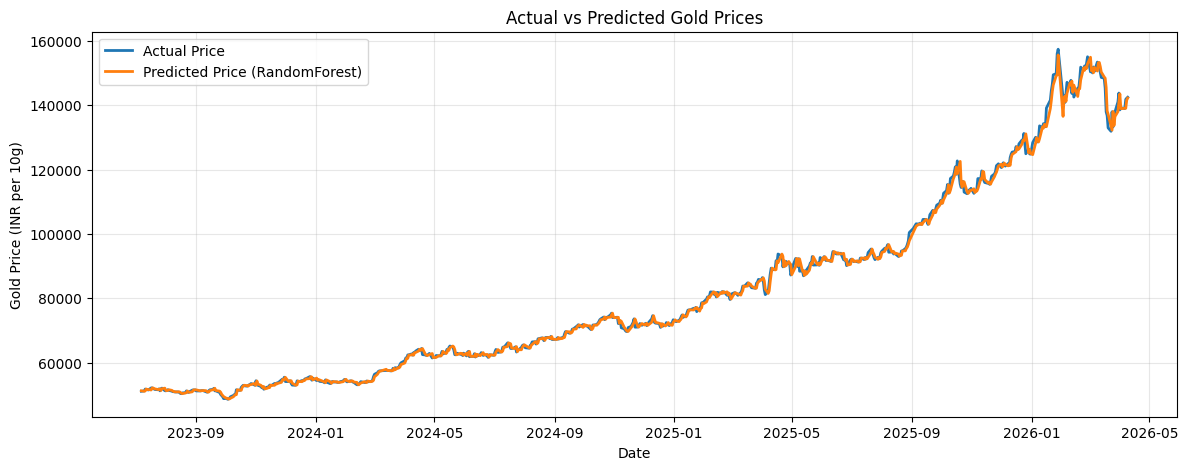

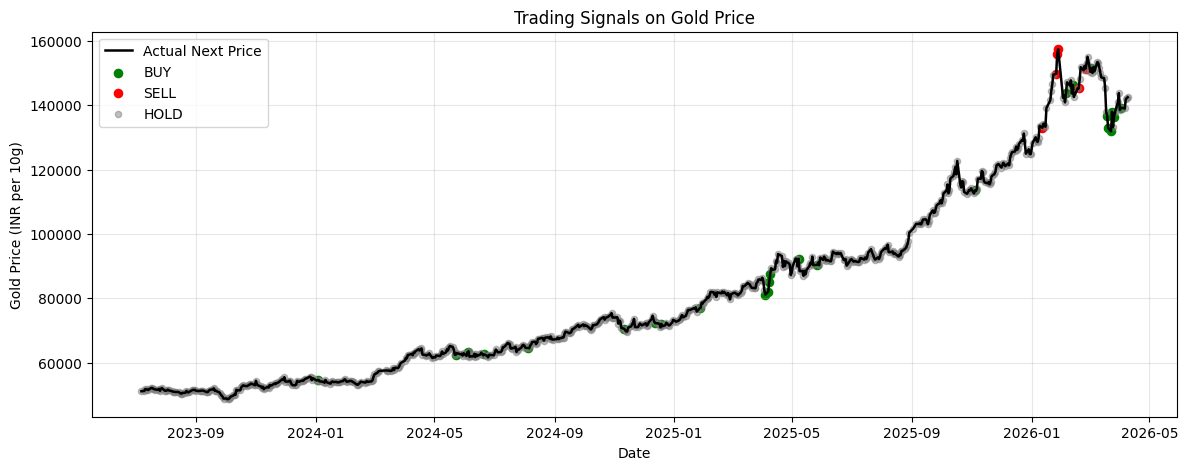

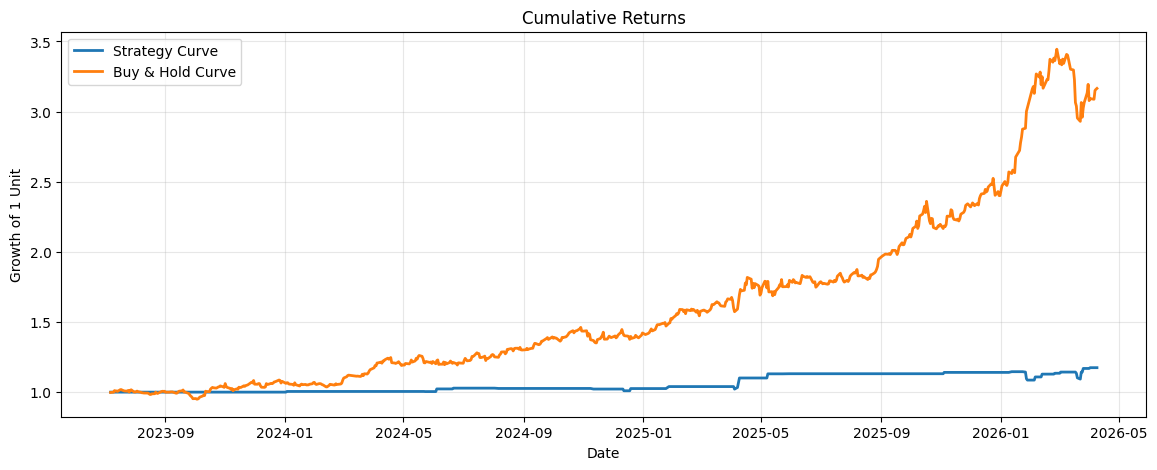

In [18]:
# ============================================================
# 18. SIMPLE VISUALIZATION DASHBOARD (MATPLOTLIB ONLY)
# ============================================================
# Goal:
# Create easy-to-read notebook charts:
# 1. Actual vs Predicted prices
# 2. Buy / Sell signals
# 3. Cumulative returns

print("Step 18: Visualization dashboard...")

import matplotlib.pyplot as plt

plt.style.use("default")

# -------------------------------
# Plot 1: Actual vs Predicted
# -------------------------------
plt.figure(figsize=(14, 5))
plt.plot(dates_test, y_test_price.values, label="Actual Price", linewidth=2)
plt.plot(dates_test, test_pred_price[strategy_model_name], label=f"Predicted Price ({strategy_model_name})", linewidth=2)
plt.title("Actual vs Predicted Gold Prices")
plt.xlabel("Date")
plt.ylabel("Gold Price (INR per 10g)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# -------------------------------
# Plot 2: Buy / Sell / Hold signals
# -------------------------------
plt.figure(figsize=(14, 5))
plt.plot(strategy_backtest_df["date"], strategy_backtest_df["next_price"], label="Actual Next Price", color="black", linewidth=1.8)

buy_points = strategy_backtest_df[strategy_backtest_df["signal"] == 1]
sell_points = strategy_backtest_df[strategy_backtest_df["signal"] == -1]
hold_points = strategy_backtest_df[strategy_backtest_df["signal"] == 0]

plt.scatter(buy_points["date"], buy_points["next_price"], color="green", label="BUY", s=35)
plt.scatter(sell_points["date"], sell_points["next_price"], color="red", label="SELL", s=35)
plt.scatter(hold_points["date"], hold_points["next_price"], color="gray", label="HOLD", s=20, alpha=0.5)

plt.title("Trading Signals on Gold Price")
plt.xlabel("Date")
plt.ylabel("Gold Price (INR per 10g)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# -------------------------------
# Plot 3: Cumulative returns
# -------------------------------
plt.figure(figsize=(14, 5))
plt.plot(strategy_backtest_df["date"], strategy_backtest_df["strategy_cumulative"], label="Strategy Curve", linewidth=2)
plt.plot(strategy_backtest_df["date"], strategy_backtest_df["buy_hold_cumulative"], label="Buy & Hold Curve", linewidth=2)

plt.title("Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Growth of 1 Unit")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Explanation
**Step 18: Visualization Dashboard**
* **Visual Analysis**: Generates three key charts using Matplotlib: the price prediction accuracy, the specific timing of BUY/SELL signals, and the growth of 1 unit of currency over time using the strategy.

In [19]:
# ============================================================
# 19. FINAL SIMPLE OUTPUT SUMMARY
# ============================================================
# Goal:
# Put the important outputs in one easy summary table.

print("Step 19: Final summary output...")

# Pick ensemble row if available, otherwise first row
if "Ensemble" in forecast_with_range_df["Model"].values:
    final_price_row = forecast_with_range_df[forecast_with_range_df["Model"] == "Ensemble"].iloc[0]
else:
    final_price_row = forecast_with_range_df.iloc[0]

final_summary_df = pd.DataFrame([{
    "Predicted Date": final_price_row["Predicted Date"],
    "Predicted Price": final_price_row["Predicted Price INR10g"],
    "Lower Bound": final_price_row["Lower Bound"],
    "Upper Bound": final_price_row["Upper Bound"],
    "Direction Prediction": latest_direction_label,
    "Probability of UP": round(latest_direction_prob_up * 100, 2),
    "Risk Level": risk_level,
    "Strategy Model": strategy_model_name,
    "Strategy Return %": round(total_strategy_return_pct, 2)
}])

display(final_summary_df)

print("Simple explanation:")
print(macro_interpretation_text)

Step 19: Final summary output...


,Predicted Date,Predicted Price,Lower Bound,Upper Bound,Direction Prediction,Probability of UP,Risk Level,Strategy Model,Strategy Return %
0,2026-04-13,142379.14,141935.89,142822.39,UP,86.82,High Risk,RandomForest,17.42


Simple explanation:
Gold may rise because the model shows a strong upward probability. Recent gold momentum appears to be an important driver. US market movement appears to be affecting the gold outlook.


### Explanation
**Step 19: Final Summary Output**
* **Final Results**: Consolidates all the most important data points—predicted price, confidence range, direction, and risk level—into a single final table for the user.